# CReST: Cross-System Profile Stability

Evaluates continuous cross-domain profile geometry, clustering safeguards, plausible-value stability, and cross-system axis stability.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# CReST cross-system profile stability environment

from pathlib import Path
import json

import numpy as np
import pandas as pd

from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score
)


BASE_DIR = Path.cwd()

HANDOFF_DIR = (
    BASE_DIR
    / "processed"
    / "crest_v5_handoff"
)

RESULTS_DIR = (
    BASE_DIR
    / "results"
)

FIG_DIR = (
    BASE_DIR
    / "figures"
)

PROFILE_BEYOND_DIR = (
    RESULTS_DIR
    / "profile_beyond_overall_proficiency"
)

HIDDEN_DOMAIN_DIR = (
    PROFILE_BEYOND_DIR
    / "hidden_target_domain_latents"
)

PROFILE_STABILITY_DIR = (
    RESULTS_DIR
    / "crosssystem_profile_stability"
)

PROFILE_STABILITY_DIR.mkdir(
    parents=True,
    exist_ok=True
)


primary_meta = pd.read_pickle(
    HANDOFF_DIR
    / "primary_meta.pkl"
)


profile_meta = pd.read_pickle(
    PROFILE_BEYOND_DIR
    / "primary_cohort_with_pisa_ct_pvs.pkl"
)


item_domain_ids = np.load(
    HANDOFF_DIR
    / "item_domain_ids.npy"
)


DOMAIN_ORDER = [
    "Written",
    "Visual",
    "Social",
    "Scientific"
]


PRIMARY_PROFILE_DOMAINS = [
    "Written",
    "Social",
    "Scientific"
]


DOMAIN_TO_ID = {
    domain:
        idx
    for idx, domain
    in enumerate(
        DOMAIN_ORDER
    )
}


print(
    "Students:",
    len(
        primary_meta
    )
)

print(
    "Systems:",
    primary_meta[
        "CNT"
    ].nunique()
)

print(
    "Primary profile domains:",
    PRIMARY_PROFILE_DOMAINS
)

Students: 142564
Systems: 63
Primary profile domains: ['Written', 'Social', 'Scientific']


In [ ]:
# Lock profile-stability protocol

PROFILE_STABILITY_PROTOCOL = {

    "primary_question":
        (
            "Do proficiency-conditioned CReST domain-relative "
            "representations support reproducible student profile "
            "structures across unseen education systems?"
        ),

    "primary_domains":
        [
            "Written",
            "Social",
            "Scientific"
        ],

    "visual_domain":
        (
            "Secondary sensitivity only because of four total items, "
            "lower source availability, and heterogeneous incremental "
            "evidence."
        ),

    "profile_basis":
        (
            "Student-level domain-relative predictions obtained from "
            "hidden-target CReST representations after conditioning "
            "domain performance on official PISA Creative Thinking "
            "proficiency."
        ),

    "overall_proficiency":
        "10 official PISA Creative Thinking plausible values",

    "model_status":
        "All CReST checkpoints frozen; no deep-model training",

    "cluster_candidates":
        [
            2,
            3,
            4,
            5
        ],

    "selection_rule":
        (
            "No cluster count will be chosen from silhouette alone. "
            "A candidate must also demonstrate stability across "
            "plausible values, resamples, and education systems."
        ),

    "interpretation_rule":
        (
            "Profiles are empirical relative-performance patterns, "
            "not giftedness categories, learner types, or fixed traits."
        ),

    "failure_rule":
        (
            "If stable profile structure is not supported, clustering "
            "will not be forced and the analysis will stop."
        )
}


with open(
    PROFILE_STABILITY_DIR
    / "profile_stability_protocol.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        PROFILE_STABILITY_PROTOCOL,
        f,
        indent=2
    )


for key, value in (
    PROFILE_STABILITY_PROTOCOL.items()
):

    print(
        f"{key}: {value}"
    )

primary_question: Do proficiency-conditioned CReST domain-relative representations support reproducible student profile structures across unseen education systems?
primary_domains: ['Written', 'Social', 'Scientific']
visual_domain: Secondary sensitivity only because of four total items, lower source availability, and heterogeneous incremental evidence.
profile_basis: Student-level domain-relative predictions obtained from hidden-target CReST representations after conditioning domain performance on official PISA Creative Thinking proficiency.
overall_proficiency: 10 official PISA Creative Thinking plausible values
model_status: All CReST checkpoints frozen; no deep-model training
cluster_candidates: [2, 3, 4, 5]
selection_rule: No cluster count will be chosen from silhouette alone. A candidate must also demonstrate stability across plausible values, resamples, and education systems.
interpretation_rule: Profiles are empirical relative-performance patterns, not giftedness categories, lea

In [ ]:
# Audit OOF domain availability for profile construction

n_students = len(
    primary_meta
)


oof_outer_fold = np.load(
    RESULTS_DIR
    / "oof_latents"
    / "oof_outer_fold.npy"
)


assert len(
    oof_outer_fold
) == n_students


availability_A = np.zeros(
    (
        n_students,
        4
    ),
    dtype=bool
)


availability_B = np.zeros(
    (
        n_students,
        4
    ),
    dtype=bool
)


assignment_A = np.zeros(
    n_students,
    dtype=np.int8
)

assignment_B = np.zeros(
    n_students,
    dtype=np.int8
)


for outer_fold in range(
    7
):

    for direction in [
        "A_to_B",
        "B_to_A"
    ]:

        path = (
            HIDDEN_DOMAIN_DIR
            /
            (
                f"fold_{outer_fold}_"
                f"test_"
                f"{direction}.npz"
            )
        )


        data = np.load(
            path
        )


        idx = (
            data[
                "handoff_row_index"
            ]
            .astype(
                np.int64
            )
        )


        avail = (
            data[
                "domain_available"
            ]
            .astype(
                bool
            )
        )


        assert avail.shape == (
            len(
                idx
            ),
            4
        )


        if direction == "A_to_B":

            assert (
                assignment_A[
                    idx
                ]
                == 0
            ).all()

            availability_A[
                idx
            ] = avail

            assignment_A[
                idx
            ] += 1


        else:

            assert (
                assignment_B[
                    idx
                ]
                == 0
            ).all()

            availability_B[
                idx
            ] = avail

            assignment_B[
                idx
            ] += 1


assert (
    assignment_A
    == 1
).all()

assert (
    assignment_B
    == 1
).all()


# Available from at least one of the two disjoint directions
availability_any = (
    availability_A
    |
    availability_B
)


# Available in both directions
availability_both = (
    availability_A
    &
    availability_B
)


audit_rows = []


for domain in DOMAIN_ORDER:

    d = DOMAIN_TO_ID[
        domain
    ]


    audit_rows.append(
        {
            "domain":
                domain,

            "available_A_percent":
                float(
                    100
                    *
                    availability_A[
                        :,
                        d
                    ].mean()
                ),

            "available_B_percent":
                float(
                    100
                    *
                    availability_B[
                        :,
                        d
                    ].mean()
                ),

            "available_any_direction_percent":
                float(
                    100
                    *
                    availability_any[
                        :,
                        d
                    ].mean()
                ),

            "available_both_directions_percent":
                float(
                    100
                    *
                    availability_both[
                        :,
                        d
                    ].mean()
                )
        }
    )


availability_audit = pd.DataFrame(
    audit_rows
)


primary_ids = [
    DOMAIN_TO_ID[
        d
    ]
    for d in PRIMARY_PROFILE_DOMAINS
]


complete_any_primary = (
    availability_any[
        :,
        primary_ids
    ]
    .all(
        axis=1
    )
)


complete_both_primary = (
    availability_both[
        :,
        primary_ids
    ]
    .all(
        axis=1
    )
)


complete_any_all4 = (
    availability_any
    .all(
        axis=1
    )
)


print(
    "DOMAIN AVAILABILITY"
)

print(
    "=" * 80
)

print(
    availability_audit.to_string(
        index=False
    )
)


print(
    "\nPRIMARY 3-DOMAIN PROFILE COVERAGE"
)

print(
    "Written + Social + Scientific "
    "available in >=1 direction:"
)

print(
    f"{complete_any_primary.sum():,} / "
    f"{n_students:,} "
    f"({100 * complete_any_primary.mean():.2f}%)"
)


print(
    "\nWritten + Social + Scientific "
    "available in BOTH directions:"
)

print(
    f"{complete_both_primary.sum():,} / "
    f"{n_students:,} "
    f"({100 * complete_both_primary.mean():.2f}%)"
)


print(
    "\nAll four domains available "
    "in >=1 direction:"
)

print(
    f"{complete_any_all4.sum():,} / "
    f"{n_students:,} "
    f"({100 * complete_any_all4.mean():.2f}%)"
)


availability_audit.to_csv(

    PROFILE_STABILITY_DIR
    / "crest_profile_domain_availability_audit.csv",

    index=False
)


np.save(
    PROFILE_STABILITY_DIR
    / "primary3_complete_any_direction.npy",
    complete_any_primary
)


print(
    "\nProfile-availability audit: PASS"
)

DOMAIN AVAILABILITY
    domain  available_A_percent  available_B_percent  available_any_direction_percent  available_both_directions_percent
   Written            99.640162            87.757779                        99.902500                          87.495441
    Visual            38.001178            39.696557                        68.031200                           9.666536
    Social            88.807132            99.797284                        99.880755                          88.723661
Scientific            69.417244            66.586936                        98.231671                          37.772509

PRIMARY 3-DOMAIN PROFILE COVERAGE
Written + Social + Scientific available in >=1 direction:
139,894 / 142,564 (98.13%)

Written + Social + Scientific available in BOTH directions:
52,684 / 142,564 (36.95%)

All four domains available in >=1 direction:
94,815 / 142,564 (66.51%)

Profile-availability audit: PASS


In [ ]:
# Helpers for leakage-free OOF domain-profile scores

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge


# Core arrays

credit_tokens = np.load(
    HANDOFF_DIR
    / "credit_tokens.npy"
)

performance_mask = np.load(
    HANDOFF_DIR
    / "performance_mask.npy"
)

interaction_mask = np.load(
    HANDOFF_DIR
    / "interaction_mask.npy"
)


assert credit_tokens.shape == (
    len(primary_meta),
    32
)

assert performance_mask.shape == (
    len(primary_meta),
    32
)

assert interaction_mask.shape == (
    len(primary_meta),
    32
)


CREATIVE_PV_COLS = [
    f"PV{i}CRTH_NC"
    for i in range(
        1,
        11
    )
]


pv_matrix_all = (
    profile_meta[
        CREATIVE_PV_COLS
    ]
    .to_numpy(
        dtype=np.float32
    )
)


country_all = (
    profile_meta[
        "CNT"
    ]
    .astype(str)
    .to_numpy()
)


# Locked A/B split

ITEM_SET_A = np.array(
    [
        0, 1, 5, 6, 7, 8, 9, 10,
        12, 15, 17, 20, 24, 27, 28, 31
    ],
    dtype=np.int64
)


ITEM_SET_B = np.array(
    [
        2, 3, 4, 11, 13, 14, 16, 18,
        19, 21, 22, 23, 25, 26, 29, 30
    ],
    dtype=np.int64
)


DIRECTION_SPECS = {

    "A_to_B": {
        "source":
            ITEM_SET_A,
        "target":
            ITEM_SET_B
    },

    "B_to_A": {
        "source":
            ITEM_SET_B,
        "target":
            ITEM_SET_A
    }
}


# Hidden target domain score

def hidden_domain_target(
    row_indices,
    target_items
):

    row_indices = np.asarray(
        row_indices,
        dtype=np.int64
    )

    target_items = np.asarray(
        target_items,
        dtype=np.int64
    )


    tokens = (
        credit_tokens[
            row_indices
        ][
            :,
            target_items
        ]
    )


    mask = (
        performance_mask[
            row_indices
        ][
            :,
            target_items
        ]
    )


    # token 1/2/3 -> credit 0/.5/1
    values = (
        tokens.astype(
            np.float32
        )
        -
        1.0
    ) / 2.0


    values = np.where(
        mask,
        values,
        0.0
    )


    n_scored = (
        mask.sum(
            axis=1
        )
    )


    score = (
        values.sum(
            axis=1
        )
        /
        np.maximum(
            n_scored,
            1
        )
    )


    score[
        n_scored == 0
    ] = np.nan


    return (
        score.astype(
            np.float32
        ),
        n_scored.astype(
            np.int16
        )
    )


# PV-conditioned residual target

def proficiency_conditioned_residual_matrix(
    domain_score,
    pv_matrix,
    countries,
    minimum_system_n=30
):

    domain_score = np.asarray(
        domain_score,
        dtype=float
    )

    pv_matrix = np.asarray(
        pv_matrix,
        dtype=float
    )

    countries = np.asarray(
        countries
    )


    residuals = np.full(
        pv_matrix.shape,
        np.nan,
        dtype=np.float32
    )


    for country in np.unique(
        countries
    ):

        idx = np.flatnonzero(
            countries
            ==
            country
        )


        idx = idx[
            np.isfinite(
                domain_score[
                    idx
                ]
            )
        ]


        if len(
            idx
        ) < minimum_system_n:

            continue


        y = (
            domain_score[
                idx
            ]
            .astype(float)
        )


        for pv_j in range(
            pv_matrix.shape[1]
        ):

            x = (
                pv_matrix[
                    idx,
                    pv_j
                ]
                .astype(float)
            )


            valid = (
                np.isfinite(x)
                &
                np.isfinite(y)
            )


            if valid.sum() < minimum_system_n:

                continue


            xv = x[
                valid
            ]

            yv = y[
                valid
            ]


            X = np.column_stack(
                [
                    np.ones(
                        len(xv)
                    ),
                    xv
                ]
            )


            beta, _, _, _ = (
                np.linalg.lstsq(
                    X,
                    yv,
                    rcond=None
                )
            )


            resid = (
                yv
                -
                X @ beta
            )


            sd = (
                resid.std(
                    ddof=1
                )
            )


            if (
                not np.isfinite(sd)
                or
                sd <= 0
            ):

                continue


            residuals[
                idx[
                    valid
                ],
                pv_j
            ] = (
                resid
                /
                sd
            ).astype(
                np.float32
            )


    return residuals


# Fixed multitarget Ridge

def fit_multitarget_ridge(
    X_train,
    Y_train,
    X_test
):

    valid = (
        np.isfinite(
            X_train
        ).all(
            axis=1
        )
        &
        np.isfinite(
            Y_train
        ).all(
            axis=1
        )
    )


    scaler = StandardScaler()


    X_train_s = (
        scaler.fit_transform(
            X_train[
                valid
            ]
        )
    )


    X_test_s = (
        scaler.transform(
            X_test
        )
    )


    probe = Ridge(
        alpha=1.0
    )


    probe.fit(
        X_train_s,
        Y_train[
            valid
        ]
    )


    return probe.predict(
        X_test_s
    ).astype(
        np.float32
    )


print(
    "Profile-score helpers: PASS"
)

Profile-score helpers: PASS


In [ ]:
# Build student-level OOF proficiency-conditioned domain profiles

n_students = len(
    primary_meta
)

n_pv = 10


PROFILE_DOMAINS = [
    "Written",
    "Social",
    "Scientific"
]


PROFILE_DOMAIN_IDS = [
    DOMAIN_TO_ID[
        d
    ]
    for d in PROFILE_DOMAINS
]


# Direction-specific predictions
# shape: students × domains × PVs

pred_domain_direction = {

    direction:
        np.full(
            (
                n_students,
                len(
                    PROFILE_DOMAINS
                ),
                n_pv
            ),
            np.nan,
            dtype=np.float32
        )

    for direction
    in DIRECTION_SPECS
}


pred_combined_direction = {

    direction:
        np.full(
            (
                n_students,
                len(
                    PROFILE_DOMAINS
                ),
                n_pv
            ),
            np.nan,
            dtype=np.float32
        )

    for direction
    in DIRECTION_SPECS
}


availability_direction = {

    direction:
        np.zeros(
            (
                n_students,
                len(
                    PROFILE_DOMAINS
                )
            ),
            dtype=bool
        )

    for direction
    in DIRECTION_SPECS
}


# Fold × direction

for outer_fold in range(
    7
):

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"OOF PROFILE PREDICTIONS — FOLD "
        f"{outer_fold}"
    )

    print(
        "=" * 72
    )


    for direction, spec in (
        DIRECTION_SPECS.items()
    ):

        val_data = np.load(
            HIDDEN_DOMAIN_DIR
            /
            (
                f"fold_{outer_fold}_"
                f"validation_"
                f"{direction}.npz"
            )
        )


        test_data = np.load(
            HIDDEN_DOMAIN_DIR
            /
            (
                f"fold_{outer_fold}_"
                f"test_"
                f"{direction}.npz"
            )
        )


        val_idx = (
            val_data[
                "handoff_row_index"
            ]
            .astype(
                np.int64
            )
        )


        test_idx = (
            test_data[
                "handoff_row_index"
            ]
            .astype(
                np.int64
            )
        )


        zg_val = (
            val_data[
                "z_general"
            ]
        )


        zg_test = (
            test_data[
                "z_general"
            ]
        )


        zd_val_all = (
            val_data[
                "z_domain_specific"
            ]
        )


        zd_test_all = (
            test_data[
                "z_domain_specific"
            ]
        )


        da_val_all = (
            val_data[
                "domain_available"
            ]
            .astype(bool)
        )


        da_test_all = (
            test_data[
                "domain_available"
            ]
            .astype(bool)
        )


        for profile_j, domain_name in enumerate(
            PROFILE_DOMAINS
        ):

            domain_id = (
                DOMAIN_TO_ID[
                    domain_name
                ]
            )


            source_items = np.array(
                [
                    i
                    for i in spec[
                        "source"
                    ]
                    if item_domain_ids[
                        i
                    ] == domain_id
                ],
                dtype=np.int64
            )


            target_items = np.array(
                [
                    i
                    for i in spec[
                        "target"
                    ]
                    if item_domain_ids[
                        i
                    ] == domain_id
                ],
                dtype=np.int64
            )


            # Validation target only

            (
                y_val,
                n_target_val
            ) = hidden_domain_target(
                val_idx,
                target_items
            )


            eligible_train = (
                da_val_all[
                    :,
                    domain_id
                ]
                &
                (
                    n_target_val
                    >= 1
                )
            )


            Y_val = (
                proficiency_conditioned_residual_matrix(

                    domain_score=(
                        y_val[
                            eligible_train
                        ]
                    ),

                    pv_matrix=(
                        pv_matrix_all[
                            val_idx[
                                eligible_train
                            ]
                        ]
                    ),

                    countries=(
                        country_all[
                            val_idx[
                                eligible_train
                            ]
                        ]
                    ),

                    minimum_system_n=30
                )
            )


            train_complete = (
                np.isfinite(
                    Y_val
                )
                .all(
                    axis=1
                )
            )


            Xd_train = (
                zd_val_all[
                    eligible_train,
                    domain_id,
                    :
                ][
                    train_complete
                ]
            )


            Xg_train = (
                zg_val[
                    eligible_train
                ][
                    train_complete
                ]
            )


            Y_train = (
                Y_val[
                    train_complete
                ]
            )


            Xc_train = np.concatenate(
                [
                    Xg_train,
                    Xd_train
                ],
                axis=1
            )


            # Predict ALL unseen test students with a valid
            # source-domain representation.
            #
            # No test target is used here.

            eligible_test = (
                da_test_all[
                    :,
                    domain_id
                ]
            )


            test_rows = (
                test_idx[
                    eligible_test
                ]
            )


            Xd_test = (
                zd_test_all[
                    eligible_test,
                    domain_id,
                    :
                ]
            )


            Xg_test_domain = (
                zg_test[
                    eligible_test
                ]
            )


            Xc_test = np.concatenate(
                [
                    Xg_test_domain,
                    Xd_test
                ],
                axis=1
            )


            pred_d = (
                fit_multitarget_ridge(
                    Xd_train,
                    Y_train,
                    Xd_test
                )
            )


            pred_c = (
                fit_multitarget_ridge(
                    Xc_train,
                    Y_train,
                    Xc_test
                )
            )


            pred_domain_direction[
                direction
            ][
                test_rows,
                profile_j,
                :
            ] = pred_d


            pred_combined_direction[
                direction
            ][
                test_rows,
                profile_j,
                :
            ] = pred_c


            availability_direction[
                direction
            ][
                test_rows,
                profile_j
            ] = True


        print(
            direction,
            "| available:",
            np.round(
                100
                *
                availability_direction[
                    direction
                ].mean(
                    axis=0
                ),
                2
            )
        )


# Integrity

for direction in DIRECTION_SPECS:

    assert (
        np.isfinite(
            pred_domain_direction[
                direction
            ]
        ).all(
            axis=2
        )
        ==
        availability_direction[
            direction
        ]
    ).all()


print(
    "\nDirection-specific OOF profile predictions: PASS"
)


OOF PROFILE PREDICTIONS — FOLD 0
A_to_B | available: [15.16 13.46 10.54]
B_to_A | available: [12.96 15.17 10.38]

OOF PROFILE PREDICTIONS — FOLD 1
A_to_B | available: [29.64 26.43 20.71]
B_to_A | available: [25.91 29.8  20.25]

OOF PROFILE PREDICTIONS — FOLD 2
A_to_B | available: [44.18 39.37 30.8 ]
B_to_A | available: [38.66 44.34 30.19]

OOF PROFILE PREDICTIONS — FOLD 3
A_to_B | available: [58.42 52.06 40.68]
B_to_A | available: [51.17 58.58 39.96]

OOF PROFILE PREDICTIONS — FOLD 4
A_to_B | available: [72.04 64.18 50.18]
B_to_A | available: [63.31 72.2  48.42]

OOF PROFILE PREDICTIONS — FOLD 5
A_to_B | available: [85.83 76.48 59.82]
B_to_A | available: [75.47 85.99 57.45]

OOF PROFILE PREDICTIONS — FOLD 6
A_to_B | available: [99.64 88.81 69.42]
B_to_A | available: [87.76 99.8  66.59]

Direction-specific OOF profile predictions: PASS


In [ ]:
# Combine directions and construct relative profile shapes

# Target item counts per domain × direction

target_item_counts = {}


for direction, spec in (
    DIRECTION_SPECS.items()
):

    target_item_counts[
        direction
    ] = {}


    for domain_name in (
        PROFILE_DOMAINS
    ):

        domain_id = (
            DOMAIN_TO_ID[
                domain_name
            ]
        )


        count = sum(
            item_domain_ids[
                i
            ] == domain_id

            for i in spec[
                "target"
            ]
        )


        target_item_counts[
            direction
        ][
            domain_name
        ] = int(
            count
        )


print(
    "Target-item reliability weights:"
)

print(
    target_item_counts
)


# Weighted direction combination

profile_domain_primary = np.full(
    (
        n_students,
        len(
            PROFILE_DOMAINS
        ),
        n_pv
    ),
    np.nan,
    dtype=np.float32
)


profile_combined_sensitivity = np.full_like(
    profile_domain_primary,
    np.nan
)


direction_count = np.zeros(
    (
        n_students,
        len(
            PROFILE_DOMAINS
        )
    ),
    dtype=np.int8
)


for domain_j, domain_name in enumerate(
    PROFILE_DOMAINS
):

    numerator_domain = np.zeros(
        (
            n_students,
            n_pv
        ),
        dtype=np.float64
    )


    numerator_combined = np.zeros(
        (
            n_students,
            n_pv
        ),
        dtype=np.float64
    )


    denominator = np.zeros(
        n_students,
        dtype=np.float64
    )


    for direction in [
        "A_to_B",
        "B_to_A"
    ]:

        available = (
            availability_direction[
                direction
            ][
                :,
                domain_j
            ]
        )


        weight = float(
            target_item_counts[
                direction
            ][
                domain_name
            ]
        )


        numerator_domain[
            available
        ] += (
            weight
            *
            pred_domain_direction[
                direction
            ][
                available,
                domain_j,
                :
            ]
        )


        numerator_combined[
            available
        ] += (
            weight
            *
            pred_combined_direction[
                direction
            ][
                available,
                domain_j,
                :
            ]
        )


        denominator[
            available
        ] += weight


        direction_count[
            available,
            domain_j
        ] += 1


    valid = (
        denominator > 0
    )


    profile_domain_primary[
        valid,
        domain_j,
        :
    ] = (

        numerator_domain[
            valid
        ]

        /

        denominator[
            valid,
            None
        ]

    ).astype(
        np.float32
    )


    profile_combined_sensitivity[
        valid,
        domain_j,
        :
    ] = (

        numerator_combined[
            valid
        ]

        /

        denominator[
            valid,
            None
        ]

    ).astype(
        np.float32
    )


# Primary complete cohort

profile_complete = (
    np.isfinite(
        profile_domain_primary
    )
    .all(
        axis=2
    )
    .all(
        axis=1
    )
)


print(
    "\nPrimary 3-domain profile N:",
    int(
        profile_complete.sum()
    )
)

print(
    "Coverage:",
    f"{100 * profile_complete.mean():.3f}%"
)


assert (
    profile_complete.sum()
    == 139894
)


# Remove each student's remaining general level:
#
# profile shape = domain score - student's 3-domain mean
#
# Done separately for every plausible value.

profile_shape_primary = (
    profile_domain_primary.copy()
)


profile_shape_sensitivity = (
    profile_combined_sensitivity.copy()
)


for pv_j in range(
    n_pv
):

    rows = np.flatnonzero(
        profile_complete
    )


    student_mean = (
        profile_shape_primary[
            rows,
            :,
            pv_j
        ]
        .mean(
            axis=1,
            keepdims=True
        )
    )


    profile_shape_primary[
        rows,
        :,
        pv_j
    ] -= student_mean


    student_mean_sens = (
        profile_shape_sensitivity[
            rows,
            :,
            pv_j
        ]
        .mean(
            axis=1,
            keepdims=True
        )
    )


    profile_shape_sensitivity[
        rows,
        :,
        pv_j
    ] -= student_mean_sens


# Sum across domains should be approximately zero
max_abs_sum = np.max(
    np.abs(
        profile_shape_primary[
            profile_complete
        ]
        .sum(
            axis=1
        )
    )
)


print(
    "Maximum |Written + Social + Scientific|:",
    f"{max_abs_sum:.8f}"
)


# Save permanent profile archive

np.savez_compressed(

    PROFILE_STABILITY_DIR
    / "crest_oof_primary3_profile_scores.npz",

    handoff_row_index=np.arange(
        n_students,
        dtype=np.int64
    ),

    domains=np.array(
        PROFILE_DOMAINS
    ),

    profile_complete=profile_complete,

    direction_count=direction_count,

    domain_prediction=profile_domain_primary,

    relative_profile=profile_shape_primary,

    combined_prediction_sensitivity=(
        profile_combined_sensitivity
    ),

    relative_profile_combined_sensitivity=(
        profile_shape_sensitivity
    )
)


print(
    "\nOOF relative-profile archive: PASS"
)

Target-item reliability weights:
{'A_to_B': {'Written': 4, 'Social': 7, 'Scientific': 3}, 'B_to_A': {'Written': 8, 'Social': 3, 'Scientific': 3}}

Primary 3-domain profile N: 139894
Coverage: 98.127%
Maximum |Written + Social + Scientific|: 0.00000024

OOF relative-profile archive: PASS


In [ ]:
# Audit profile geometry before any clustering

profile_rows = np.flatnonzero(
    profile_complete
)


audit_rows = []


for pv_j in range(
    10
):

    X = (
        profile_shape_primary[
            profile_rows,
            :,
            pv_j
        ]
    )


    # covariance eigenvalues
    covariance = np.cov(
        X,
        rowvar=False
    )


    eigenvalues = np.linalg.eigvalsh(
        covariance
    )[::-1]


    # Pairwise domain correlations
    corr = np.corrcoef(
        X,
        rowvar=False
    )


    audit_rows.append(
        {
            "pv":
                pv_j + 1,

            "written_sd":
                float(
                    X[
                        :,
                        0
                    ].std(
                        ddof=1
                    )
                ),

            "social_sd":
                float(
                    X[
                        :,
                        1
                    ].std(
                        ddof=1
                    )
                ),

            "scientific_sd":
                float(
                    X[
                        :,
                        2
                    ].std(
                        ddof=1
                    )
                ),

            "written_social_r":
                float(
                    corr[
                        0,
                        1
                    ]
                ),

            "written_scientific_r":
                float(
                    corr[
                        0,
                        2
                    ]
                ),

            "social_scientific_r":
                float(
                    corr[
                        1,
                        2
                    ]
                ),

            "eigenvalue_1":
                float(
                    eigenvalues[
                        0
                    ]
                ),

            "eigenvalue_2":
                float(
                    eigenvalues[
                        1
                    ]
                ),

            "eigenvalue_3":
                float(
                    eigenvalues[
                        2
                    ]
                )
        }
    )


profile_geometry = pd.DataFrame(
    audit_rows
)


profile_geometry.to_csv(

    PROFILE_STABILITY_DIR
    / "crest_profile_geometry_by_pv.csv",

    index=False
)


print(
    profile_geometry.to_string(
        index=False
    )
)


print(
    "\nMEAN ACROSS 10 PLAUSIBLE VALUES"
)

print(
    profile_geometry[
        [
            "written_sd",
            "social_sd",
            "scientific_sd",
            "written_social_r",
            "written_scientific_r",
            "social_scientific_r",
            "eigenvalue_1",
            "eigenvalue_2",
            "eigenvalue_3"
        ]
    ]
    .mean()
    .to_string()
)

 pv  written_sd  social_sd  scientific_sd  written_social_r  written_scientific_r  social_scientific_r  eigenvalue_1  eigenvalue_2  eigenvalue_3
  1    0.170688   0.245966       0.203144         -0.576017             -0.142793            -0.726810      0.092844      0.038057  1.908578e-16
  2    0.170943   0.246365       0.203376         -0.576471             -0.142203            -0.726838      0.093133      0.038146  1.564617e-16
  3    0.170990   0.246360       0.204391         -0.571575             -0.147643            -0.727168      0.093281      0.038426  1.882551e-16
  4    0.170481   0.246457       0.204104         -0.572948             -0.143425            -0.728942      0.093356      0.038107  1.548731e-16
  5    0.171251   0.246897       0.204649         -0.572399             -0.146235            -0.727455      0.093670      0.038496  2.313074e-16
  6    0.170938   0.246039       0.202708         -0.578547             -0.141054            -0.725888      0.092806      0.038040

In [ ]:
# Exact 2D orthonormal coordinates for relative profiles

import numpy as np


profile_rows = np.flatnonzero(
    profile_complete
)


# Orthonormal basis for the zero-sum profile plane
#
# Domain order:
# Written, Social, Scientific
#
# Axis 1 ~ Written vs Social
# Axis 2 ~ (Written + Social) vs Scientific

PROFILE_BASIS = np.array(
    [
        [
            1.0 / np.sqrt(2.0),
            1.0 / np.sqrt(6.0)
        ],
        [
            -1.0 / np.sqrt(2.0),
            1.0 / np.sqrt(6.0)
        ],
        [
            0.0,
            -2.0 / np.sqrt(6.0)
        ]
    ],
    dtype=np.float64
)


# Orthonormality
assert np.allclose(
    PROFILE_BASIS.T @ PROFILE_BASIS,
    np.eye(2),
    atol=1e-12
)


# Basis lies in zero-sum plane
assert np.allclose(
    PROFILE_BASIS.sum(
        axis=0
    ),
    0.0,
    atol=1e-12
)


# Students × PVs × 2 profile coordinates

profile_coords_2d = np.empty(
    (
        len(
            profile_rows
        ),
        10,
        2
    ),
    dtype=np.float32
)


for pv_j in range(
    10
):

    X3 = (
        profile_shape_primary[
            profile_rows,
            :,
            pv_j
        ]
        .astype(
            np.float64
        )
    )


    X2 = (
        X3
        @
        PROFILE_BASIS
    )


    # Exact reconstruction from 2D coordinates
    X3_reconstructed = (
        X2
        @
        PROFILE_BASIS.T
    )


    max_error = np.max(
        np.abs(
            X3
            -
            X3_reconstructed
        )
    )


    assert max_error < 1e-6


    profile_coords_2d[
        :,
        pv_j,
        :
    ] = X2.astype(
        np.float32
    )


print(
    "Profile students:",
    profile_coords_2d.shape[0]
)

print(
    "2D coordinate shape:",
    profile_coords_2d.shape
)


# Variance decomposition

variance_rows = []


for pv_j in range(
    10
):

    X = (
        profile_coords_2d[
            :,
            pv_j,
            :
        ]
    )


    eig = np.linalg.eigvalsh(
        np.cov(
            X,
            rowvar=False
        )
    )[::-1]


    variance_rows.append(
        {
            "pv":
                pv_j + 1,

            "eigenvalue_1":
                float(
                    eig[0]
                ),

            "eigenvalue_2":
                float(
                    eig[1]
                ),

            "dimension_1_share":
                float(
                    eig[0]
                    /
                    eig.sum()
                ),

            "dimension_2_share":
                float(
                    eig[1]
                    /
                    eig.sum()
                )
        }
    )


profile_2d_variance = pd.DataFrame(
    variance_rows
)


print(
    "\n2D variance structure"
)

print(
    profile_2d_variance.to_string(
        index=False
    )
)


print(
    "\nMean dimension shares:"
)

print(
    profile_2d_variance[
        [
            "dimension_1_share",
            "dimension_2_share"
        ]
    ]
    .mean()
    .to_string()
)


np.save(
    PROFILE_STABILITY_DIR
    / "crest_primary3_profile_coordinates_2d.npy",
    profile_coords_2d
)


print(
    "\nExact 2D profile representation: PASS"
)

Profile students: 139894
2D coordinate shape: (139894, 10, 2)

2D variance structure
 pv  eigenvalue_1  eigenvalue_2  dimension_1_share  dimension_2_share
  1      0.092844      0.038057           0.709270           0.290730
  2      0.093133      0.038146           0.709430           0.290570
  3      0.093281      0.038426           0.708247           0.291753
  4      0.093356      0.038107           0.710131           0.289869
  5      0.093670      0.038496           0.708729           0.291271
  6      0.092806      0.038040           0.709278           0.290722
  7      0.093415      0.038400           0.708684           0.291316
  8      0.093124      0.038102           0.709648           0.290352
  9      0.093736      0.038841           0.707029           0.292971
 10      0.093150      0.038169           0.709343           0.290657

Mean dimension shares:
dimension_1_share    0.708979
dimension_2_share    0.291021

Exact 2D profile representation: PASS


In [ ]:
# Candidate profile-structure stability benchmark

from itertools import combinations

from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


K_CANDIDATES = [
    2,
    3,
    4,
    5
]


CLUSTER_SEED = 20261018

rng_cluster = np.random.default_rng(
    CLUSTER_SEED
)


fold_membership_complete = (
    oof_outer_fold[
        profile_rows
    ]
)


# PART A
# Fit each candidate separately for all 10 plausible values

pv_labels = {}

pv_fit_rows = []


for k in K_CANDIDATES:

    print(
        "\n"
        + "=" * 76
    )

    print(
        f"GLOBAL PV FITS — k={k}"
    )

    print(
        "=" * 76
    )


    labels_k = np.empty(
        (
            10,
            len(
                profile_rows
            )
        ),
        dtype=np.int16
    )


    for pv_j in range(
        10
    ):

        X = (
            profile_coords_2d[
                :,
                pv_j,
                :
            ]
        )


        km = KMeans(
            n_clusters=k,
            n_init=10,
            max_iter=300,
            random_state=(
                CLUSTER_SEED
                +
                1000 * k
                +
                pv_j
            ),
            algorithm="lloyd"
        )


        labels = (
            km.fit_predict(
                X
            )
        )


        labels_k[
            pv_j
        ] = labels


        counts = np.bincount(
            labels,
            minlength=k
        )


        min_cluster_share = (
            counts.min()
            /
            counts.sum()
        )


        sil = silhouette_score(
            X,
            labels,
            sample_size=min(
                5000,
                len(
                    X
                )
            ),
            random_state=(
                CLUSTER_SEED
                +
                pv_j
            )
        )


        db = davies_bouldin_score(
            X,
            labels
        )


        ch = calinski_harabasz_score(
            X,
            labels
        )


        pv_fit_rows.append(
            {
                "k":
                    k,

                "pv":
                    pv_j + 1,

                "silhouette":
                    float(
                        sil
                    ),

                "davies_bouldin":
                    float(
                        db
                    ),

                "calinski_harabasz":
                    float(
                        ch
                    ),

                "minimum_cluster_share":
                    float(
                        min_cluster_share
                    )
            }
        )


    pv_labels[
        k
    ] = labels_k


pv_fit_df = pd.DataFrame(
    pv_fit_rows
)


# PART B
# Plausible-value stability:
# pairwise ARI across 10 PV-specific clusterings

pv_stability_rows = []


for k in K_CANDIDATES:

    pair_aris = []


    for pv_a, pv_b in combinations(
        range(
            10
        ),
        2
    ):

        ari = adjusted_rand_score(
            pv_labels[
                k
            ][
                pv_a
            ],
            pv_labels[
                k
            ][
                pv_b
            ]
        )


        pair_aris.append(
            ari
        )


    pv_stability_rows.append(
        {
            "k":
                k,

            "pv_ari_mean":
                float(
                    np.mean(
                        pair_aris
                    )
                ),

            "pv_ari_median":
                float(
                    np.median(
                        pair_aris
                    )
                ),

            "pv_ari_min":
                float(
                    np.min(
                        pair_aris
                    )
                ),

            "pv_ari_max":
                float(
                    np.max(
                        pair_aris
                    )
                )
        }
    )


pv_stability_df = pd.DataFrame(
    pv_stability_rows
)


# PART C
# Random split-half resampling stability
#
# Two independently fitted KMeans solutions are compared
# on a common anchor set. PV cycles across repetitions.

N_RESAMPLE_REPS = 12

anchor_size = min(
    30000,
    len(
        profile_rows
    )
)


anchor_idx = rng_cluster.choice(
    len(
        profile_rows
    ),
    size=anchor_size,
    replace=False
)


resample_rows = []


for k in K_CANDIDATES:

    rep_aris = []


    for rep in range(
        N_RESAMPLE_REPS
    ):

        pv_j = (
            rep
            %
            10
        )


        X = (
            profile_coords_2d[
                :,
                pv_j,
                :
            ]
        )


        permutation = (
            rng_cluster.permutation(
                len(
                    X
                )
            )
        )


        half = (
            len(
                X
            )
            //
            2
        )


        idx_a = (
            permutation[
                :half
            ]
        )


        idx_b = (
            permutation[
                half:
            ]
        )


        km_a = KMeans(
            n_clusters=k,
            n_init=10,
            max_iter=300,
            random_state=(
                CLUSTER_SEED
                +
                100000
                +
                1000 * k
                +
                rep
            ),
            algorithm="lloyd"
        )


        km_b = KMeans(
            n_clusters=k,
            n_init=10,
            max_iter=300,
            random_state=(
                CLUSTER_SEED
                +
                200000
                +
                1000 * k
                +
                rep
            ),
            algorithm="lloyd"
        )


        km_a.fit(
            X[
                idx_a
            ]
        )


        km_b.fit(
            X[
                idx_b
            ]
        )


        labels_a = (
            km_a.predict(
                X[
                    anchor_idx
                ]
            )
        )


        labels_b = (
            km_b.predict(
                X[
                    anchor_idx
                ]
            )
        )


        ari = adjusted_rand_score(
            labels_a,
            labels_b
        )


        rep_aris.append(
            ari
        )


        resample_rows.append(
            {
                "k":
                    k,

                "rep":
                    rep + 1,

                "pv":
                    pv_j + 1,

                "ari":
                    float(
                        ari
                    )
            }
        )


resample_df = pd.DataFrame(
    resample_rows
)


# PART D
# Cross-system stability
#
# For each outer fold:
# - fit one clustering on the other systems
# - fit one independently on the held-out systems
# - compare their induced partitions on a common anchor set
#
# Repeated separately for all 10 PVs.

system_rows = []


for k in K_CANDIDATES:

    print(
        f"\nCross-system stability k={k}"
    )


    for outer_fold in range(
        7
    ):

        train_mask = (
            fold_membership_complete
            !=
            outer_fold
        )


        heldout_mask = (
            fold_membership_complete
            ==
            outer_fold
        )


        assert train_mask.sum() > 0

        assert heldout_mask.sum() > 0


        for pv_j in range(
            10
        ):

            X = (
                profile_coords_2d[
                    :,
                    pv_j,
                    :
                ]
            )


            km_train = KMeans(
                n_clusters=k,
                n_init=10,
                max_iter=300,
                random_state=(
                    CLUSTER_SEED
                    +
                    300000
                    +
                    10000 * k
                    +
                    100 * outer_fold
                    +
                    pv_j
                ),
                algorithm="lloyd"
            )


            km_heldout = KMeans(
                n_clusters=k,
                n_init=10,
                max_iter=300,
                random_state=(
                    CLUSTER_SEED
                    +
                    400000
                    +
                    10000 * k
                    +
                    100 * outer_fold
                    +
                    pv_j
                ),
                algorithm="lloyd"
            )


            km_train.fit(
                X[
                    train_mask
                ]
            )


            km_heldout.fit(
                X[
                    heldout_mask
                ]
            )


            labels_train_geometry = (
                km_train.predict(
                    X[
                        anchor_idx
                    ]
                )
            )


            labels_heldout_geometry = (
                km_heldout.predict(
                    X[
                        anchor_idx
                    ]
                )
            )


            ari = adjusted_rand_score(
                labels_train_geometry,
                labels_heldout_geometry
            )


            system_rows.append(
                {
                    "k":
                        k,

                    "outer_fold":
                        outer_fold,

                    "pv":
                        pv_j + 1,

                    "ari":
                        float(
                            ari
                        ),

                    "n_train_students":
                        int(
                            train_mask.sum()
                        ),

                    "n_heldout_students":
                        int(
                            heldout_mask.sum()
                        )
                }
            )


system_stability_df = pd.DataFrame(
    system_rows
)


# PART E
# Candidate summary

fit_summary = (

    pv_fit_df

    .groupby(
        "k",
        as_index=False
    )

    .agg(
        silhouette_mean=(
            "silhouette",
            "mean"
        ),

        silhouette_min=(
            "silhouette",
            "min"
        ),

        davies_bouldin_mean=(
            "davies_bouldin",
            "mean"
        ),

        calinski_harabasz_mean=(
            "calinski_harabasz",
            "mean"
        ),

        minimum_cluster_share_mean=(
            "minimum_cluster_share",
            "mean"
        ),

        minimum_cluster_share_min=(
            "minimum_cluster_share",
            "min"
        )
    )
)


resample_summary = (

    resample_df

    .groupby(
        "k",
        as_index=False
    )

    .agg(
        resample_ari_mean=(
            "ari",
            "mean"
        ),

        resample_ari_median=(
            "ari",
            "median"
        ),

        resample_ari_min=(
            "ari",
            "min"
        )
    )
)


system_summary = (

    system_stability_df

    .groupby(
        "k",
        as_index=False
    )

    .agg(
        system_ari_mean=(
            "ari",
            "mean"
        ),

        system_ari_median=(
            "ari",
            "median"
        ),

        system_ari_min=(
            "ari",
            "min"
        )
    )
)


cluster_candidate_summary = (

    fit_summary

    .merge(
        pv_stability_df,
        on="k"
    )

    .merge(
        resample_summary,
        on="k"
    )

    .merge(
        system_summary,
        on="k"
    )
)


cluster_candidate_summary.to_csv(
    PROFILE_STABILITY_DIR
    / "crest_profile_cluster_candidate_stability.csv",
    index=False
)


pv_fit_df.to_csv(
    PROFILE_STABILITY_DIR
    / "crest_profile_cluster_pv_fit_metrics.csv",
    index=False
)


resample_df.to_csv(
    PROFILE_STABILITY_DIR
    / "crest_profile_cluster_resampling_stability.csv",
    index=False
)


system_stability_df.to_csv(
    PROFILE_STABILITY_DIR
    / "crest_profile_cluster_crosssystem_stability.csv",
    index=False
)


print(
    "\n"
    + "=" * 100
)

print(
    "CLUSTER CANDIDATE SUMMARY"
)

print(
    "=" * 100
)


print(
    cluster_candidate_summary.to_string(
        index=False
    )
)


GLOBAL PV FITS — k=2

GLOBAL PV FITS — k=3

GLOBAL PV FITS — k=4

GLOBAL PV FITS — k=5

Cross-system stability k=2

Cross-system stability k=3

Cross-system stability k=4

Cross-system stability k=5

CLUSTER CANDIDATE SUMMARY
 k  silhouette_mean  silhouette_min  davies_bouldin_mean  calinski_harabasz_mean  minimum_cluster_share_mean  minimum_cluster_share_min  pv_ari_mean  pv_ari_median  pv_ari_min  pv_ari_max  resample_ari_mean  resample_ari_median  resample_ari_min  system_ari_mean  system_ari_median  system_ari_min
 2         0.370723        0.362038             0.999511           108754.214807                    0.496300                   0.490743     0.907252       0.907350    0.899523    0.916990           0.965284             0.969765          0.911258         0.800121           0.809474        0.570291
 3         0.339376        0.331560             1.012963           100284.172778                    0.253252                   0.246322     0.888778       0.890438    0.861667  

In [ ]:
# Interpret the k=2 candidate and construct PV-consensus assignments

from scipy.optimize import linear_sum_assignment


K_PRIMARY_CANDIDATE = 2

labels_raw = (
    pv_labels[
        K_PRIMARY_CANDIDATE
    ]
    .copy()
)


n_profile_students = len(
    profile_rows
)


# 1. Reference centroids from PV1

X_ref = (
    profile_coords_2d[
        :,
        0,
        :
    ]
)


reference_labels = (
    labels_raw[
        0
    ]
)


reference_centroids = np.vstack(
    [
        X_ref[
            reference_labels == c
        ].mean(
            axis=0
        )

        for c in range(
            K_PRIMARY_CANDIDATE
        )
    ]
)


# 2. Align cluster labels across all 10 PVs

aligned_labels = np.empty_like(
    labels_raw
)


aligned_labels[
    0
] = reference_labels


alignment_rows = []


for pv_j in range(
    10
):

    X = (
        profile_coords_2d[
            :,
            pv_j,
            :
        ]
    )


    current_labels = (
        labels_raw[
            pv_j
        ]
    )


    current_centroids = np.vstack(
        [
            X[
                current_labels == c
            ].mean(
                axis=0
            )

            for c in range(
                K_PRIMARY_CANDIDATE
            )
        ]
    )


    cost = np.linalg.norm(
        current_centroids[
            :,
            None,
            :
        ]
        -
        reference_centroids[
            None,
            :,
            :
        ],
        axis=2
    )


    row_ind, col_ind = (
        linear_sum_assignment(
            cost
        )
    )


    mapping = {
        int(current):
            int(reference)

        for current, reference
        in zip(
            row_ind,
            col_ind
        )
    }


    aligned = np.array(
        [
            mapping[
                int(label)
            ]
            for label
            in current_labels
        ],
        dtype=np.int16
    )


    aligned_labels[
        pv_j
    ] = aligned


    alignment_rows.append(
        {
            "pv":
                pv_j + 1,

            "mapping":
                str(
                    mapping
                ),

            "agreement_with_pv1":
                float(
                    adjusted_rand_score(
                        aligned_labels[
                            0
                        ],
                        aligned
                    )
                )
        }
    )


alignment_df = pd.DataFrame(
    alignment_rows
)


# 3. Student-level consensus and assignment stability

cluster_counts = np.stack(
    [
        (
            aligned_labels
            == c
        ).sum(
            axis=0
        )

        for c in range(
            K_PRIMARY_CANDIDATE
        )
    ],
    axis=1
)


consensus_label = (
    cluster_counts.argmax(
        axis=1
    )
    .astype(
        np.int16
    )
)


consensus_count = (
    cluster_counts.max(
        axis=1
    )
)


consensus_stability = (
    consensus_count
    /
    10.0
)


consensus_tie = (
    cluster_counts[
        :,
        0
    ]
    ==
    cluster_counts[
        :,
        1
    ]
)


# 4. Centroids in interpretable 3-domain space

centroid_rows = []


for pv_j in range(
    10
):

    X3 = (
        profile_shape_primary[
            profile_rows,
            :,
            pv_j
        ]
    )


    for cluster_id in range(
        2
    ):

        mask = (
            aligned_labels[
                pv_j
            ]
            ==
            cluster_id
        )


        centroid = (
            X3[
                mask
            ].mean(
                axis=0
            )
        )


        centroid_rows.append(
            {
                "pv":
                    pv_j + 1,

                "cluster":
                    cluster_id,

                "n_students":
                    int(
                        mask.sum()
                    ),

                "written":
                    float(
                        centroid[
                            0
                        ]
                    ),

                "social":
                    float(
                        centroid[
                            1
                        ]
                    ),

                "scientific":
                    float(
                        centroid[
                            2
                        ]
                    )
            }
        )


centroid_by_pv = pd.DataFrame(
    centroid_rows
)


centroid_summary = (

    centroid_by_pv

    .groupby(
        "cluster",
        as_index=False
    )

    .agg(
        written_mean=(
            "written",
            "mean"
        ),

        written_sd=(
            "written",
            "std"
        ),

        social_mean=(
            "social",
            "mean"
        ),

        social_sd=(
            "social",
            "std"
        ),

        scientific_mean=(
            "scientific",
            "mean"
        ),

        scientific_sd=(
            "scientific",
            "std"
        ),

        mean_n_students=(
            "n_students",
            "mean"
        )
    )
)


# 5. Consensus prevalence

consensus_prevalence = (

    pd.Series(
        consensus_label
    )

    .value_counts(
        normalize=True
    )

    .sort_index()
)


# 6. Cross-system consensus prevalence

profile_country = (
    country_all[
        profile_rows
    ]
)


system_prevalence_rows = []


for country in np.unique(
    profile_country
):

    mask = (
        profile_country
        ==
        country
    )


    for cluster_id in range(
        2
    ):

        system_prevalence_rows.append(
            {
                "country":
                    country,

                "cluster":
                    cluster_id,

                "n_students":
                    int(
                        mask.sum()
                    ),

                "prevalence":
                    float(
                        np.mean(
                            consensus_label[
                                mask
                            ]
                            ==
                            cluster_id
                        )
                    )
            }
        )


system_prevalence_df = pd.DataFrame(
    system_prevalence_rows
)


# 7. Save

np.savez_compressed(

    PROFILE_STABILITY_DIR
    / "crest_k2_pv_consensus_assignments.npz",

    handoff_row_index=(
        profile_rows.astype(
            np.int64
        )
    ),

    aligned_labels=(
        aligned_labels
    ),

    consensus_label=(
        consensus_label
    ),

    consensus_stability=(
        consensus_stability.astype(
            np.float32
        )
    ),

    consensus_tie=(
        consensus_tie
    )
)


centroid_by_pv.to_csv(
    PROFILE_STABILITY_DIR
    / "crest_k2_centroids_by_pv.csv",
    index=False
)


centroid_summary.to_csv(
    PROFILE_STABILITY_DIR
    / "crest_k2_centroid_summary.csv",
    index=False
)


system_prevalence_df.to_csv(
    PROFILE_STABILITY_DIR
    / "crest_k2_system_prevalence.csv",
    index=False
)


# 8. Output

print(
    "K=2 CENTROIDS IN RELATIVE DOMAIN SCORE SPACE"
)

print(
    "=" * 80
)

print(
    centroid_summary.to_string(
        index=False
    )
)


print(
    "\nCONSENSUS PREVALENCE"
)

for cluster_id, prevalence in (
    consensus_prevalence.items()
):

    print(
        f"Cluster {cluster_id}: "
        f"{100 * prevalence:.2f}%"
    )


print(
    "\nPV ASSIGNMENT STABILITY"
)

print(
    "100% identical across 10 PVs:",
    f"{100 * np.mean(consensus_stability == 1.0):.2f}%"
)

print(
    ">=90% agreement:",
    f"{100 * np.mean(consensus_stability >= 0.9):.2f}%"
)

print(
    ">=80% agreement:",
    f"{100 * np.mean(consensus_stability >= 0.8):.2f}%"
)

print(
    "5-vs-5 ties:",
    f"{100 * np.mean(consensus_tie):.3f}%"
)


print(
    "\nSYSTEM PREVALENCE RANGE"
)

for cluster_id in range(
    2
):

    temp = (
        system_prevalence_df[
            system_prevalence_df[
                "cluster"
            ]
            ==
            cluster_id
        ][
            "prevalence"
        ]
    )

    print(
        f"Cluster {cluster_id}: "
        f"min={100 * temp.min():.1f}%, "
        f"median={100 * temp.median():.1f}%, "
        f"max={100 * temp.max():.1f}%"
    )

K=2 CENTROIDS IN RELATIVE DOMAIN SCORE SPACE
 cluster  written_mean  written_sd  social_mean  social_sd  scientific_mean  scientific_sd  mean_n_students
       0     -0.089581    0.001246     0.173393   0.001635        -0.083812       0.001512          69496.8
       1      0.039572    0.001734    -0.211424   0.001948         0.171853       0.001791          70397.2

CONSENSUS PREVALENCE
Cluster 0: 49.91%
Cluster 1: 50.09%

PV ASSIGNMENT STABILITY
100% identical across 10 PVs: 93.58%
>=90% agreement: 95.75%
>=80% agreement: 97.21%
5-vs-5 ties: 0.530%

SYSTEM PREVALENCE RANGE
Cluster 0: min=25.0%, median=50.3%, max=61.7%
Cluster 1: min=38.3%, median=49.7%, max=75.0%


In [ ]:
# Continuum-vs-cluster safeguard using matched Gaussian null

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


GAUSSIAN_NULL_SEED = 20261019

rng_null = np.random.default_rng(
    GAUSSIAN_NULL_SEED
)


NULL_REPS = 20

NULL_SAMPLE_N = min(
    20000,
    len(
        profile_rows
    )
)

SILHOUETTE_SAMPLE_N = 5000


def clustering_geometry(
    X,
    seed
):

    km = KMeans(
        n_clusters=2,
        n_init=10,
        max_iter=300,
        random_state=seed,
        algorithm="lloyd"
    )


    labels = (
        km.fit_predict(
            X
        )
    )


    silhouette = (
        silhouette_score(
            X,
            labels,
            sample_size=min(
                SILHOUETTE_SAMPLE_N,
                len(
                    X
                )
            ),
            random_state=seed
        )
    )


    centers = (
        km.cluster_centers_
    )


    centroid_distance = (
        np.linalg.norm(
            centers[
                0
            ]
            -
            centers[
                1
            ]
        )
    )


    residual = (
        X
        -
        centers[
            labels
        ]
    )


    pooled_within_rmse = np.sqrt(
        np.mean(
            np.sum(
                residual ** 2,
                axis=1
            )
        )
    )


    separation_ratio = (
        centroid_distance
        /
        pooled_within_rmse
    )


    cluster_share = np.bincount(
        labels,
        minlength=2
    ) / len(
        labels
    )


    return {
        "silhouette":
            float(
                silhouette
            ),

        "separation_ratio":
            float(
                separation_ratio
            ),

        "minimum_cluster_share":
            float(
                cluster_share.min()
            )
    }


null_rows = []


for pv_j in range(
    10
):

    print(
        f"Gaussian-null safeguard PV{pv_j + 1}"
    )


    X_full = (
        profile_coords_2d[
            :,
            pv_j,
            :
        ]
        .astype(
            np.float64
        )
    )


    sample_idx = rng_null.choice(
        len(
            X_full
        ),
        size=NULL_SAMPLE_N,
        replace=False
    )


    X_obs = (
        X_full[
            sample_idx
        ]
    )


    observed = clustering_geometry(
        X_obs,
        seed=(
            GAUSSIAN_NULL_SEED
            +
            pv_j
        )
    )


    mu = (
        X_full.mean(
            axis=0
        )
    )


    cov = np.cov(
        X_full,
        rowvar=False
    )


    null_silhouettes = []
    null_separations = []
    null_min_shares = []


    for rep in range(
        NULL_REPS
    ):

        X_null = (
            rng_null.multivariate_normal(
                mean=mu,
                cov=cov,
                size=NULL_SAMPLE_N
            )
        )


        null_geometry = (
            clustering_geometry(
                X_null,
                seed=(
                    GAUSSIAN_NULL_SEED
                    +
                    10000
                    +
                    100 * pv_j
                    +
                    rep
                )
            )
        )


        null_silhouettes.append(
            null_geometry[
                "silhouette"
            ]
        )


        null_separations.append(
            null_geometry[
                "separation_ratio"
            ]
        )


        null_min_shares.append(
            null_geometry[
                "minimum_cluster_share"
            ]
        )


    null_silhouettes = np.asarray(
        null_silhouettes
    )


    null_separations = np.asarray(
        null_separations
    )


    null_rows.append(
        {
            "pv":
                pv_j + 1,

            "observed_silhouette":
                observed[
                    "silhouette"
                ],

            "null_silhouette_mean":
                float(
                    null_silhouettes.mean()
                ),

            "null_silhouette_sd":
                float(
                    null_silhouettes.std(
                        ddof=1
                    )
                ),

            "silhouette_excess":
                float(
                    observed[
                        "silhouette"
                    ]
                    -
                    null_silhouettes.mean()
                ),

            "silhouette_empirical_p":
                float(
                    (
                        1
                        +
                        np.sum(
                            null_silhouettes
                            >=
                            observed[
                                "silhouette"
                            ]
                        )
                    )
                    /
                    (
                        NULL_REPS
                        +
                        1
                    )
                ),

            "observed_separation":
                observed[
                    "separation_ratio"
                ],

            "null_separation_mean":
                float(
                    null_separations.mean()
                ),

            "separation_excess":
                float(
                    observed[
                        "separation_ratio"
                    ]
                    -
                    null_separations.mean()
                ),

            "observed_min_cluster_share":
                observed[
                    "minimum_cluster_share"
                ],

            "null_min_cluster_share_mean":
                float(
                    np.mean(
                        null_min_shares
                    )
                )
        }
    )


gaussian_null_df = pd.DataFrame(
    null_rows
)


gaussian_null_df.to_csv(

    PROFILE_STABILITY_DIR
    / "crest_k2_matched_gaussian_null.csv",

    index=False
)


print(
    "\n"
    + "=" * 105
)

print(
    "MATCHED-GAUSSIAN NULL RESULTS"
)

print(
    "=" * 105
)


print(
    gaussian_null_df.to_string(
        index=False
    )
)


print(
    "\nMEAN ACROSS 10 PLAUSIBLE VALUES"
)

print(
    gaussian_null_df[
        [
            "observed_silhouette",
            "null_silhouette_mean",
            "silhouette_excess",
            "observed_separation",
            "null_separation_mean",
            "separation_excess"
        ]
    ]
    .mean()
    .to_string()
)

Gaussian-null safeguard PV1
Gaussian-null safeguard PV2
Gaussian-null safeguard PV3
Gaussian-null safeguard PV4
Gaussian-null safeguard PV5
Gaussian-null safeguard PV6
Gaussian-null safeguard PV7
Gaussian-null safeguard PV8
Gaussian-null safeguard PV9
Gaussian-null safeguard PV10

MATCHED-GAUSSIAN NULL RESULTS
 pv  observed_silhouette  null_silhouette_mean  null_silhouette_sd  silhouette_excess  silhouette_empirical_p  observed_separation  null_separation_mean  separation_excess  observed_min_cluster_share  null_min_cluster_share_mean
  1             0.369598              0.381991            0.003661          -0.012393                     1.0             1.763540              1.812732          -0.049192                     0.49285                     0.496380
  2             0.374080              0.383703            0.004207          -0.009623                     1.0             1.779214              1.814653          -0.035439                     0.50000                     0.494490
 

In [ ]:
# Derive the two continuous domain-relative profile dimensions

from scipy.optimize import linear_sum_assignment


# 1. Covariance matrix for each plausible value
#    Domain order: Written, Social, Scientific

pv_covariances = []


for pv_j in range(
    10
):

    X = (
        profile_shape_primary[
            profile_rows,
            :,
            pv_j
        ]
        .astype(
            np.float64
        )
    )


    cov = np.cov(
        X,
        rowvar=False
    )


    pv_covariances.append(
        cov
    )


pv_covariances = np.stack(
    pv_covariances,
    axis=0
)


# 2. Consensus covariance across 10 plausible values

consensus_cov = (
    pv_covariances.mean(
        axis=0
    )
)


eigvals, eigvecs = (
    np.linalg.eigh(
        consensus_cov
    )
)


order = np.argsort(
    eigvals
)[::-1]


eigvals = eigvals[
    order
]


eigvecs = eigvecs[
    :,
    order
]


# Two non-zero dimensions only
consensus_axes = (
    eigvecs[
        :,
        :2
    ]
    .copy()
)


# 3. Fix signs for interpretability
#
# Axis 1: Social loading positive
# Axis 2: Written loading positive

if (
    consensus_axes[
        1,
        0
    ]
    < 0
):

    consensus_axes[
        :,
        0
    ] *= -1


if (
    consensus_axes[
        0,
        1
    ]
    < 0
):

    consensus_axes[
        :,
        1
    ] *= -1


nonzero_variance = (
    eigvals[
        :2
    ].sum()
)


explained_share = (
    eigvals[
        :2
    ]
    /
    nonzero_variance
)


axis_loading_df = pd.DataFrame(
    {
        "domain":
            PROFILE_DOMAINS,

        "dimension_1_loading":
            consensus_axes[
                :,
                0
            ],

        "dimension_2_loading":
            consensus_axes[
                :,
                1
            ]
    }
)


print(
    "CONSENSUS DOMAIN-RELATIVE DIMENSIONS"
)

print(
    "=" * 72
)

print(
    axis_loading_df.to_string(
        index=False
    )
)


print(
    "\nEigenvalues:"
)

print(
    eigvals
)


print(
    "\nShare of non-zero profile variance:"
)

print(
    f"Dimension 1: "
    f"{100 * explained_share[0]:.2f}%"
)

print(
    f"Dimension 2: "
    f"{100 * explained_share[1]:.2f}%"
)


# 4. Verify axis orientation separately for all 10 PVs

pv_axis_rows = []


for pv_j in range(
    10
):

    vals, vecs = np.linalg.eigh(
        pv_covariances[
            pv_j
        ]
    )


    order = np.argsort(
        vals
    )[::-1]


    vals = vals[
        order
    ]


    vecs = vecs[
        :,
        order
    ][
        :,
        :2
    ]


    # Match PV axes to consensus axes
    similarity = np.abs(
        vecs.T
        @
        consensus_axes
    )


    rows, cols = (
        linear_sum_assignment(
            -similarity
        )
    )


    aligned = np.zeros_like(
        consensus_axes
    )


    aligned_vals = np.zeros(
        2
    )


    for source_axis, consensus_axis in zip(
        rows,
        cols
    ):

        v = (
            vecs[
                :,
                source_axis
            ]
            .copy()
        )


        if (
            np.dot(
                v,
                consensus_axes[
                    :,
                    consensus_axis
                ]
            )
            < 0
        ):

            v *= -1


        aligned[
            :,
            consensus_axis
        ] = v


        aligned_vals[
            consensus_axis
        ] = vals[
            source_axis
        ]


    for axis_j in range(
        2
    ):

        cosine = float(
            np.dot(
                aligned[
                    :,
                    axis_j
                ],
                consensus_axes[
                    :,
                    axis_j
                ]
            )
        )


        cosine = np.clip(
            cosine,
            -1.0,
            1.0
        )


        angle = float(
            np.degrees(
                np.arccos(
                    cosine
                )
            )
        )


        pv_axis_rows.append(
            {
                "pv":
                    pv_j + 1,

                "dimension":
                    axis_j + 1,

                "cosine_with_consensus":
                    cosine,

                "angle_degrees":
                    angle,

                "eigenvalue":
                    float(
                        aligned_vals[
                            axis_j
                        ]
                    )
            }
        )


pv_axis_stability_df = pd.DataFrame(
    pv_axis_rows
)


print(
    "\nPV-TO-CONSENSUS AXIS STABILITY"
)

print(
    "=" * 72
)


print(
    pv_axis_stability_df
    .groupby(
        "dimension"
    )
    .agg(
        mean_cosine=(
            "cosine_with_consensus",
            "mean"
        ),

        min_cosine=(
            "cosine_with_consensus",
            "min"
        ),

        mean_angle_deg=(
            "angle_degrees",
            "mean"
        ),

        max_angle_deg=(
            "angle_degrees",
            "max"
        )
    )
    .to_string()
)


# Save

np.save(
    PROFILE_STABILITY_DIR
    / "crest_continuous_profile_axes.npy",
    consensus_axes
)


axis_loading_df.to_csv(
    PROFILE_STABILITY_DIR
    / "crest_continuous_profile_axis_loadings.csv",
    index=False
)


pv_axis_stability_df.to_csv(
    PROFILE_STABILITY_DIR
    / "crest_continuous_profile_pv_stability.csv",
    index=False
)


print(
    "\nContinuous profile dimensions: PASS"
)

CONSENSUS DOMAIN-RELATIVE DIMENSIONS
    domain  dimension_1_loading  dimension_2_loading
   Written            -0.258494             0.774498
    Social             0.799982            -0.163387
Scientific            -0.541489            -0.611111

Eigenvalues:
[9.32503043e-02 3.82795306e-02 1.70434901e-16]

Share of non-zero profile variance:
Dimension 1: 70.90%
Dimension 2: 29.10%

PV-TO-CONSENSUS AXIS STABILITY
           mean_cosine  min_cosine  mean_angle_deg  max_angle_deg
dimension                                                        
1             0.999989    0.999959        0.216761       0.517765
2             0.999989    0.999959        0.216761       0.517765

Continuous profile dimensions: PASS


In [ ]:
# Cross-system stability of continuous profile dimensions

SYSTEM_AXIS_MIN_N = 100


profile_country = (
    country_all[
        profile_rows
    ]
)


system_axis_rows = []


for country in np.unique(
    profile_country
):

    country_mask = (
        profile_country
        ==
        country
    )


    n_country = int(
        country_mask.sum()
    )


    if (
        n_country
        <
        SYSTEM_AXIS_MIN_N
    ):

        continue


    for pv_j in range(
        10
    ):

        X = (
            profile_shape_primary[
                profile_rows[
                    country_mask
                ],
                :,
                pv_j
            ]
            .astype(
                np.float64
            )
        )


        cov = np.cov(
            X,
            rowvar=False
        )


        vals, vecs = np.linalg.eigh(
            cov
        )


        order = np.argsort(
            vals
        )[::-1]


        vals = vals[
            order
        ]


        vecs = (
            vecs[
                :,
                order
            ][
                :,
                :2
            ]
        )


        # Match local axes to global consensus

        similarity = np.abs(
            vecs.T
            @
            consensus_axes
        )


        rows, cols = (
            linear_sum_assignment(
                -similarity
            )
        )


        aligned = np.zeros_like(
            consensus_axes
        )


        aligned_vals = np.zeros(
            2
        )


        for source_axis, consensus_axis in zip(
            rows,
            cols
        ):

            v = (
                vecs[
                    :,
                    source_axis
                ]
                .copy()
            )


            if (
                np.dot(
                    v,
                    consensus_axes[
                        :,
                        consensus_axis
                    ]
                )
                < 0
            ):

                v *= -1


            aligned[
                :,
                consensus_axis
            ] = v


            aligned_vals[
                consensus_axis
            ] = vals[
                source_axis
            ]


        for axis_j in range(
            2
        ):

            cosine = float(
                np.dot(
                    aligned[
                        :,
                        axis_j
                    ],
                    consensus_axes[
                        :,
                        axis_j
                    ]
                )
            )


            cosine = float(
                np.clip(
                    cosine,
                    -1,
                    1
                )
            )


            angle = float(
                np.degrees(
                    np.arccos(
                        cosine
                    )
                )
            )


            system_axis_rows.append(
                {
                    "country":
                        country,

                    "n_students":
                        n_country,

                    "pv":
                        pv_j + 1,

                    "dimension":
                        axis_j + 1,

                    "cosine_with_global":
                        cosine,

                    "angle_degrees":
                        angle,

                    "eigenvalue":
                        float(
                            aligned_vals[
                                axis_j
                            ]
                        )
                }
            )


system_axis_df = pd.DataFrame(
    system_axis_rows
)


# Average over 10 plausible values within each system

system_axis_summary = (

    system_axis_df

    .groupby(
        [
            "country",
            "dimension"
        ],
        as_index=False
    )

    .agg(
        n_students=(
            "n_students",
            "first"
        ),

        mean_cosine=(
            "cosine_with_global",
            "mean"
        ),

        min_cosine=(
            "cosine_with_global",
            "min"
        ),

        mean_angle_deg=(
            "angle_degrees",
            "mean"
        ),

        max_angle_deg=(
            "angle_degrees",
            "max"
        )
    )
)


overall_axis_summary = (

    system_axis_summary

    .groupby(
        "dimension"
    )

    .agg(
        n_systems=(
            "country",
            "nunique"
        ),

        mean_cosine=(
            "mean_cosine",
            "mean"
        ),

        median_cosine=(
            "mean_cosine",
            "median"
        ),

        minimum_cosine=(
            "mean_cosine",
            "min"
        ),

        mean_angle_deg=(
            "mean_angle_deg",
            "mean"
        ),

        median_angle_deg=(
            "mean_angle_deg",
            "median"
        ),

        maximum_mean_angle_deg=(
            "mean_angle_deg",
            "max"
        )
    )
)


print(
    "CROSS-SYSTEM CONTINUOUS-AXIS STABILITY"
)

print(
    "=" * 80
)

print(
    overall_axis_summary.to_string()
)


print(
    "\nSYSTEMS WITH LARGEST ORIENTATION DIFFERENCES"
)

print(
    "=" * 80
)


for dimension in [
    1,
    2
]:

    print(
        f"\nDimension {dimension}"
    )


    print(
        system_axis_summary[
            system_axis_summary[
                "dimension"
            ]
            ==
            dimension
        ]
        .sort_values(
            "mean_angle_deg",
            ascending=False
        )
        .head(
            10
        )
        .to_string(
            index=False
        )
    )


system_axis_df.to_csv(
    PROFILE_STABILITY_DIR
    / "crest_continuous_profile_axes_63system_by_pv.csv",
    index=False
)


system_axis_summary.to_csv(
    PROFILE_STABILITY_DIR
    / "crest_continuous_profile_axes_63system_summary.csv",
    index=False
)


print(
    "\nCross-system continuous-axis analysis: PASS"
)

CROSS-SYSTEM CONTINUOUS-AXIS STABILITY
           n_systems  mean_cosine  median_cosine  minimum_cosine  mean_angle_deg  median_angle_deg  maximum_mean_angle_deg
dimension                                                                                                                 
1                 63     0.988693       0.995333        0.876487         6.89853          5.430389               28.757312
2                 63     0.988693       0.995333        0.876487         6.89853          5.430389               28.757312

SYSTEMS WITH LARGEST ORIENTATION DIFFERENCES

Dimension 1
country  dimension  n_students  mean_cosine  min_cosine  mean_angle_deg  max_angle_deg
    MAR          1        1877     0.876487    0.859417       28.757312      30.748819
    SAU          1        2148     0.938771    0.914204       20.097872      23.907096
    DOM          1        1915     0.944318    0.932786       19.170225      21.126570
    KOR          1        1781     0.959619    0.940925       

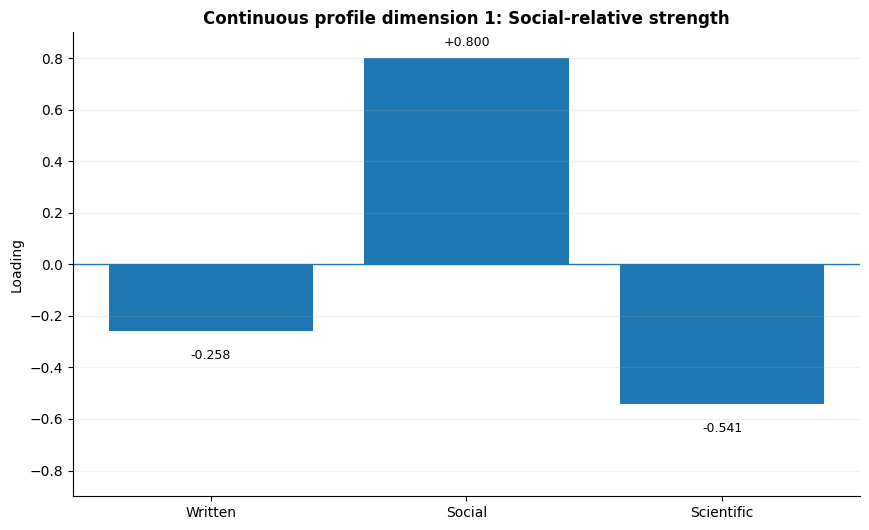

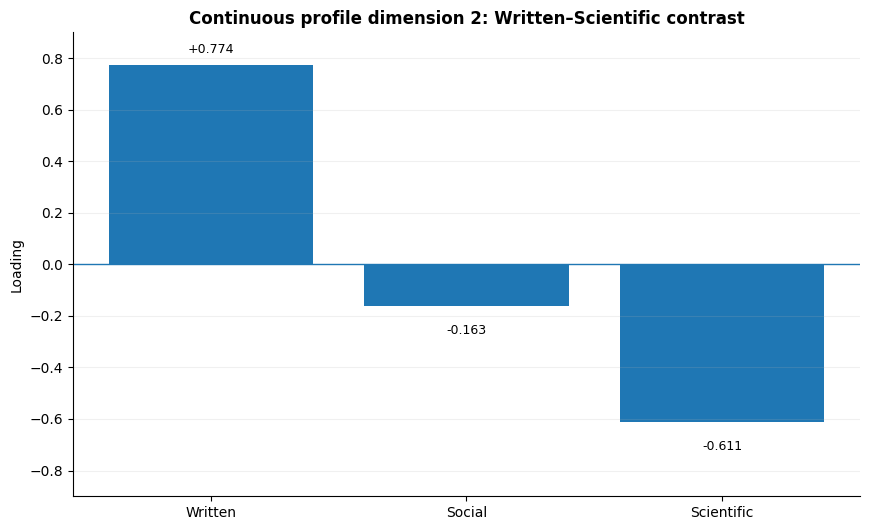

In [ ]:
# Publication figure for the two continuous profile dimensions

import matplotlib.pyplot as plt
import numpy as np


domains = [
    "Written",
    "Social",
    "Scientific"
]


x = np.arange(
    len(domains)
)


# Dimension 1

fig, ax = plt.subplots(
    figsize=(8.8, 5.4)
)


ax.bar(
    x,
    consensus_axes[
        :,
        0
    ]
)


ax.axhline(
    0,
    linewidth=1
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    domains
)


ax.set_ylabel(
    "Loading"
)


ax.set_title(
    "Continuous profile dimension 1: Social-relative strength",
    fontweight="semibold"
)


ax.set_ylim(
    -0.9,
    0.9
)


ax.grid(
    axis="y",
    alpha=0.18
)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


for i, value in enumerate(
    consensus_axes[
        :,
        0
    ]
):

    ax.text(
        i,
        value
        +
        (
            0.035
            if value >= 0
            else -0.07
        ),
        f"{value:+.3f}",
        ha="center",
        va=(
            "bottom"
            if value >= 0
            else "top"
        ),
        fontsize=9
    )


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_continuous_profile_dimension1.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_continuous_profile_dimension1.png",
    dpi=400,
    bbox_inches="tight"
)


plt.show()


# Dimension 2

fig, ax = plt.subplots(
    figsize=(8.8, 5.4)
)


ax.bar(
    x,
    consensus_axes[
        :,
        1
    ]
)


ax.axhline(
    0,
    linewidth=1
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    domains
)


ax.set_ylabel(
    "Loading"
)


ax.set_title(
    "Continuous profile dimension 2: Written–Scientific contrast",
    fontweight="semibold"
)


ax.set_ylim(
    -0.9,
    0.9
)


ax.grid(
    axis="y",
    alpha=0.18
)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


for i, value in enumerate(
    consensus_axes[
        :,
        1
    ]
):

    ax.text(
        i,
        value
        +
        (
            0.035
            if value >= 0
            else -0.07
        ),
        f"{value:+.3f}",
        ha="center",
        va=(
            "bottom"
            if value >= 0
            else "top"
        ),
        fontsize=9
    )


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_continuous_profile_dimension2.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_continuous_profile_dimension2.png",
    dpi=400,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# Lock final conclusions from cross-system profile analysis

import json


crosssystem_thresholds = []


for dimension in [
    1,
    2
]:

    temp = (
        system_axis_summary[
            system_axis_summary[
                "dimension"
            ]
            ==
            dimension
        ]
        .copy()
    )


    crosssystem_thresholds.append(
        {
            "dimension":
                dimension,

            "systems":
                int(
                    len(temp)
                ),

            "mean_cosine":
                float(
                    temp[
                        "mean_cosine"
                    ].mean()
                ),

            "median_cosine":
                float(
                    temp[
                        "mean_cosine"
                    ].median()
                ),

            "pct_systems_cosine_ge_0_95":
                float(
                    100
                    *
                    (
                        temp[
                            "mean_cosine"
                        ]
                        >= 0.95
                    ).mean()
                ),

            "pct_systems_cosine_ge_0_90":
                float(
                    100
                    *
                    (
                        temp[
                            "mean_cosine"
                        ]
                        >= 0.90
                    ).mean()
                ),

            "pct_systems_angle_lt_10deg":
                float(
                    100
                    *
                    (
                        temp[
                            "mean_angle_deg"
                        ]
                        < 10
                    ).mean()
                ),

            "pct_systems_angle_lt_15deg":
                float(
                    100
                    *
                    (
                        temp[
                            "mean_angle_deg"
                        ]
                        < 15
                    ).mean()
                )
        }
    )


crosssystem_threshold_df = pd.DataFrame(
    crosssystem_thresholds
)


print(
    "CROSS-SYSTEM STABILITY THRESHOLDS"
)

print(
    "=" * 80
)

print(
    crosssystem_threshold_df.to_string(
        index=False
    )
)


locked_profile_findings = {

    "status":
        "LOCKED",

    "primary_profile_cohort":
        139894,

    "primary_profile_coverage_percent":
        98.13,

    "primary_domains":
        [
            "Written",
            "Social",
            "Scientific"
        ],

    "visual_status":
        (
            "Secondary only because of sparse item coverage "
            "and heterogeneous prior evidence."
        ),

    "profile_geometry":
        "Continuous two-dimensional zero-sum domain-relative space",

    "dimension_1":
        {
            "name":
                "Social-relative strength",

            "variance_share_percent":
                float(
                    100
                    *
                    explained_share[
                        0
                    ]
                ),

            "written_loading":
                float(
                    consensus_axes[
                        0,
                        0
                    ]
                ),

            "social_loading":
                float(
                    consensus_axes[
                        1,
                        0
                    ]
                ),

            "scientific_loading":
                float(
                    consensus_axes[
                        2,
                        0
                    ]
                )
        },

    "dimension_2":
        {
            "name":
                "Written-Scientific contrast",

            "variance_share_percent":
                float(
                    100
                    *
                    explained_share[
                        1
                    ]
                ),

            "written_loading":
                float(
                    consensus_axes[
                        0,
                        1
                    ]
                ),

            "social_loading":
                float(
                    consensus_axes[
                        1,
                        1
                    ]
                ),

            "scientific_loading":
                float(
                    consensus_axes[
                        2,
                        1
                    ]
                )
        },

    "pv_axis_stability":
        {
            "mean_cosine":
                float(
                    pv_axis_stability_df[
                        "cosine_with_consensus"
                    ].mean()
                ),

            "maximum_angle_degrees":
                float(
                    pv_axis_stability_df[
                        "angle_degrees"
                    ].max()
                )
        },

    "cross_system_axis_stability":
        {
            "systems":
                63,

            "mean_cosine":
                float(
                    system_axis_summary[
                        "mean_cosine"
                    ].mean()
                ),

            "median_cosine":
                float(
                    system_axis_summary[
                        "mean_cosine"
                    ].median()
                ),

            "mean_angle_degrees":
                float(
                    system_axis_summary[
                        "mean_angle_deg"
                    ].mean()
                ),

            "maximum_mean_angle_degrees":
                float(
                    system_axis_summary[
                        "mean_angle_deg"
                    ].max()
                )
        },

    "clustering_safeguard":
        {
            "best_stability_candidate":
                2,

            "observed_mean_silhouette":
                float(
                    gaussian_null_df[
                        "observed_silhouette"
                    ].mean()
                ),

            "matched_gaussian_mean_silhouette":
                float(
                    gaussian_null_df[
                        "null_silhouette_mean"
                    ].mean()
                ),

            "observed_mean_separation":
                float(
                    gaussian_null_df[
                        "observed_separation"
                    ].mean()
                ),

            "matched_gaussian_mean_separation":
                float(
                    gaussian_null_df[
                        "null_separation_mean"
                    ].mean()
                ),

            "decision":
                (
                    "Do not interpret stable k=2 partition as "
                    "discrete learner types. Matched unimodal "
                    "Gaussian structure clusters at least as strongly."
                )
        },

    "interpretation":
        (
            "CReST supports continuous, reproducible domain-relative "
            "creative-performance dimensions rather than discrete "
            "student typologies."
        )
}


with open(
    PROFILE_STABILITY_DIR
    / "crest_crosssystem_profile_findings_LOCKED.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        locked_profile_findings,
        f,
        indent=2
    )


print(
    "\nProfile-stability findings: LOCKED"
)

CROSS-SYSTEM STABILITY THRESHOLDS
 dimension  systems  mean_cosine  median_cosine  pct_systems_cosine_ge_0_95  pct_systems_cosine_ge_0_90  pct_systems_angle_lt_10deg  pct_systems_angle_lt_15deg
         1       63     0.988693       0.995333                   95.238095                   98.412698                   82.539683                   92.063492
         2       63     0.988693       0.995333                   95.238095                   98.412698                   82.539683                   92.063492

Notebook 10 findings: LOCKED
